In [1]:
# import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Analysis Workflow

1. **Data Collection** – Load the Telco Customer Churn dataset
2. **Data Understanding** – Inspect shape, columns, data types, and unique values
3. **Data Cleaning & Preprocessing** – Handle empty values and correct data types
4. **EDA** – Analyze distributions and descriptive statistics
5. **Graphical Analysis** – Use histograms, box plots, and correlation analysis
6. **Insights & Conclusion** – Summarize the important findings


In [2]:
df = pd.read_csv("/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.shape

(7043, 21)

In [4]:
# information about the data

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
# Drop "Customer ID" column no need in analysis and modeling

df = df.drop("customerID", axis=1)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
col_list = df.columns
print(col_list)

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


In [7]:
# Display unique values from categorical columns
Num_col = ["tenure", "MonthlyCharges", "TotalCharges"]

for col in col_list:
    if col not in Num_col:
        print(f"Column: {col}")
        print(f"Unique Values: {df[col].unique()}")
        print("-"*70)

Column: gender
Unique Values: ['Female' 'Male']
----------------------------------------------------------------------
Column: SeniorCitizen
Unique Values: [0 1]
----------------------------------------------------------------------
Column: Partner
Unique Values: ['Yes' 'No']
----------------------------------------------------------------------
Column: Dependents
Unique Values: ['No' 'Yes']
----------------------------------------------------------------------
Column: PhoneService
Unique Values: ['No' 'Yes']
----------------------------------------------------------------------
Column: MultipleLines
Unique Values: ['No phone service' 'No' 'Yes']
----------------------------------------------------------------------
Column: InternetService
Unique Values: ['DSL' 'Fiber optic' 'No']
----------------------------------------------------------------------
Column: OnlineSecurity
Unique Values: ['No' 'Yes' 'No internet service']
----------------------------------------------------------------

In [8]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [9]:
# empty values in TotalCharges column
df[df["TotalCharges"] == ' ']

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [10]:
# no. of record those are empty
len(df[df["TotalCharges"] == ' '])

11

In [11]:
# Replace empty values with zero

df["TotalCharges"] = df["TotalCharges"].replace({' ': '0.0'})

In [12]:
# convert totalcharges column into float
df["TotalCharges"] = df["TotalCharges"].astype(float)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [14]:
# Distribution of targeted column

df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

## EDA

Exploratory Data Analysis is performed to understand the distribution of customer characteristics and identify patterns that may be related to churn.

### Numerical Feature Summary

The main numerical features analyzed are:

* `tenure`
* `MonthlyCharges`
* `TotalCharges`

Descriptive statistics are used to examine their central tendency, spread, and range.


In [15]:
df.shape

(7043, 20)

In [16]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [17]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [18]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


## Graphical Analysis

Visualizations are used to understand the distribution of numerical variables and identify potential outliers.

The analysis includes:

* Distribution of customer tenure
* Distribution of monthly charges
* Distribution of total charges
* Box plots for identifying potential outliers
* Correlation analysis between numerical variables


In [19]:
def histogram_plot(df, column_name):

    plt.figure(figsize = (5,3))
    sns.histplot(df[column_name], kde = True)
    plt.title(f"Distrubution of {column_name}")

    # calculate mean and median
    mean_col = df[column_name].mean()
    median_col = df[column_name].median()

    # adding vertical lines for mean and median
    plt.axvline(mean_col, color = 'red', linestyle = '--', label = "mean")
    plt.axvline(median_col, color = 'green', linestyle = '-', label = "median")

    plt.legend()
    plt.show()
    

In [20]:
def boxplot_graph(df, column_name):

    plt.figure(figsize = (5,3))
    sns.boxplot(y = df[column_name])
    plt.title(f"Distrubution of {column_name}")
    plt.ylabel(column_name)
    plt.show()

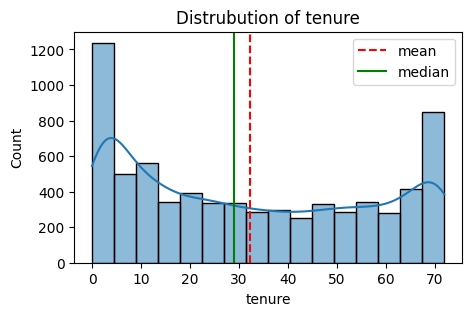

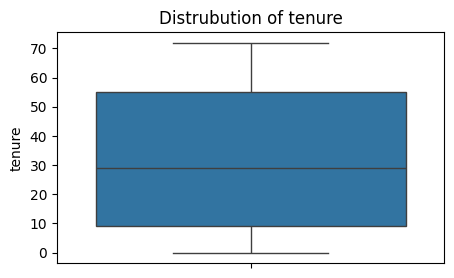

In [21]:
histogram_plot(df, "tenure")
boxplot_graph(df, "tenure")

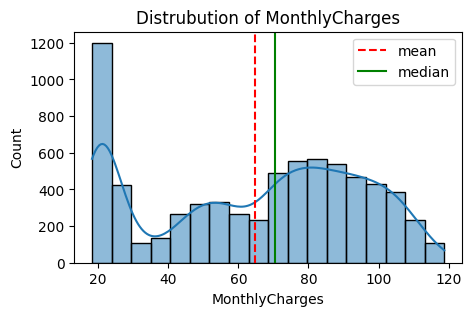

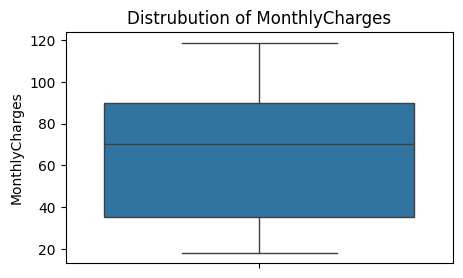

In [22]:
histogram_plot(df, "MonthlyCharges")
boxplot_graph(df, "MonthlyCharges")

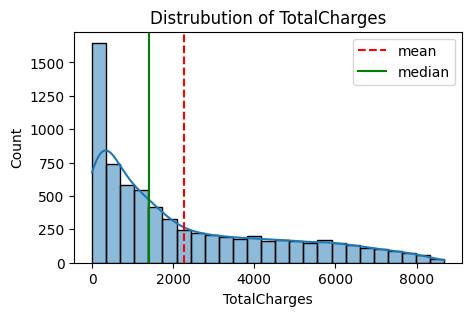

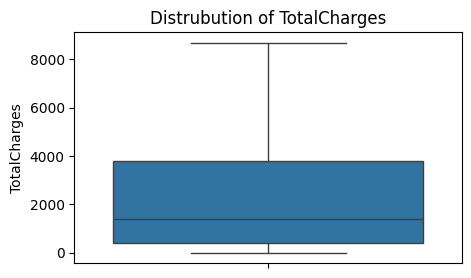

In [23]:
histogram_plot(df, "TotalCharges")
boxplot_graph(df, "TotalCharges")

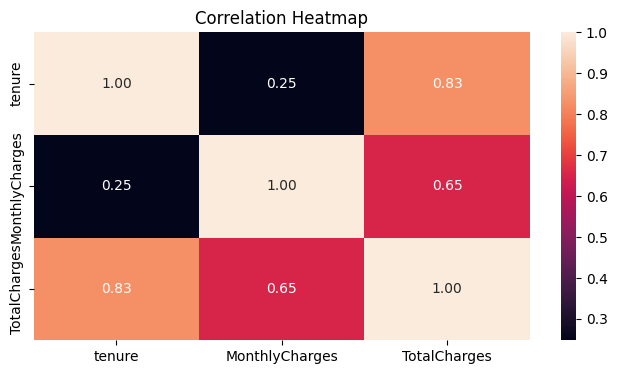

In [24]:
plt.figure(figsize = (8, 4))
sns.color_palette("Spectral", as_cmap = True)
sns.heatmap(df[Num_col].corr(), annot = True, fmt = ".2f")
plt.title("Correlation Heatmap")
plt.show()

## Key Insights

Based on the exploratory analysis:

* The dataset contains **7,043 customers** after loading and **20 analytical features** after removing the customer identifier.
* The target variable `Churn` contains **1,869 churned customers** and **5,174 customers who did not churn**.
* `TotalCharges` required preprocessing because it contained blank values and was initially stored as an object.
* Customer `tenure`, `MonthlyCharges`, and `TotalCharges` show different distributions and ranges.
* The correlation analysis helps identify relationships among the numerical variables.
* The analysis provides a foundation for identifying customer segments that may have a higher risk of churn.

## Conclusion

This project demonstrates a complete basic data-analysis workflow, including data inspection, cleaning, preprocessing, exploratory analysis, and visualization using Python.

The next step could be to investigate how categorical variables such as contract type, internet service, payment method, and technical support are associated with customer churn and eventually build a machine-learning model to predict churn.
